In [2]:
%pip install gensim
%pip install pyldavis

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pyLDAvis-3.4.1-py3-none-any.whl.metadata (4.2 kB)
  Using cached funcy-2.0-py2.py3-none-any.whl.metadata (5.9 kB)
Using cached pyLDAvis-3.4.1-py3-none-any.whl (2.6 MB)
Using cached funcy-2.0-py2.py3-none-any.whl (30 kB)

   ---------------------------------------- 0/3 [funcy]
   ---------------------------------------- 0/3 [funcy]
   ---------------------------------------- 0/3 [funcy]
   ------------- -------------------------- 1/3 [numexpr]
   ------------- -------------------------- 1/3 [numexpr]
   -------------------------- ------------- 2/3 [pyldavis]
   -------------------------- ------------- 2/3 [pyldavis]
   -------------------------- ------------- 2/3 [pyldavis]
   -------------------------- ------------- 2/3 [pyldavis]
   -------------------------- ------------- 2/3 [pyldavis]
   -------------------------- ------------- 2/3 [pyldavis]
   -------------------------- ------------- 2/3 [pyldavis]
   -------------------------- ------------- 2/3 [pyldavis]
   -----


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
from toolbox_tm import *
from pathlib import Path

PATH_100_NOVELS = Path ("../corpora/100_English_Novels/raw/corpus")
PATH_100_NOVELS_LEMMA = Path ("../corpora/100_English_Novels/lemmatized/corpus")
PATH_SMALL_COLLECTION = Path ('../corpora/A_Small_Collection_of_British_Fiction/lemmatized/corpus')

#### Loading the corpus

In [6]:
processed = load_corpus (PATH_SMALL_COLLECTION, exclude_stop_words= True, drop_ners = True)

# Quick look at what one document looks like after processing
first_doc = next(iter(processed))
print(f"\nFirst document: {first_doc}")
print(f"First 20 tokens: {', '.join (processed[first_doc][:20])}")

Loaded 27 documents, 2,608,097 tokens total.

First document: ABronte_Agnes_lemmatized.txt
First 20 tokens: parsonage, true, history, contain, instruction, though, treasure, may, hard, find, find, trivial, quantity, dry, shrivelled, kernel, scarcely, compensate, trouble, crack


#### Building the vocabulary

In [7]:
dictionary = build_dictionary (processed, min_df = 2, max_df = 0.8)

Vocabulary: 73,141 unique words -> 23,741 after filtering
  Kept words appearing in at least 2 document(s) and at most 80% of 27 documents.


#### Fitting the LDA model

In [8]:
lda_model = fit_lda (processed, dictionary, num_topics = 30, passes=15)

Training LDA: num_topics=30, passes=15 ...
Done. Model has 30 topics over a vocabulary of 23,741 words.


#### Visualizing results

In [9]:
top_words_per_topic(lda_model, n = 15)

+----------+-------------------+--------------------+-------------------+--------------------+--------------------+-----------------------+--------------------+-------------------+--------------------+-------------------------+-------------------------+-------------------------+------------------------+----------------------+------------------------+
| Topic    | #1                | #2                 | #3                | #4                 | #5                 | #6                    | #7                 | #8                | #9                 | #10                     | #11                     | #12                     | #13                    | #14                  | #15                    |
+----------+-------------------+--------------------+-------------------+--------------------+--------------------+-----------------------+--------------------+-------------------+--------------------+-------------------------+-------------------------+-------------------------+---------------

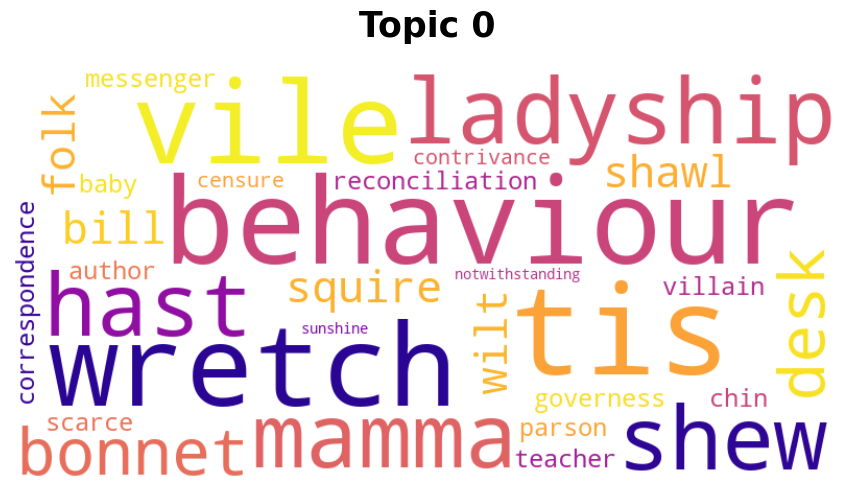

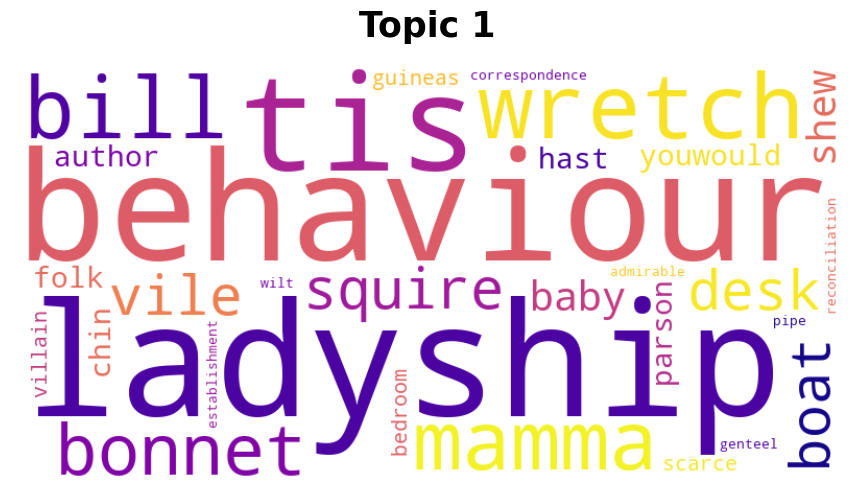

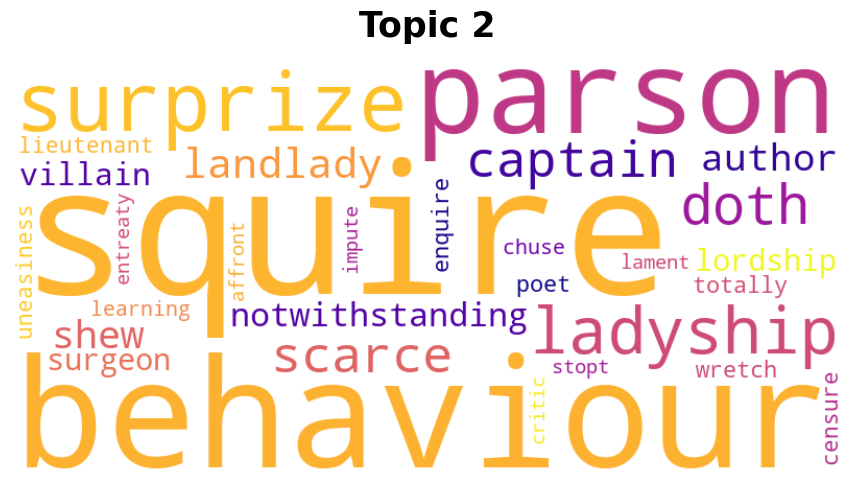

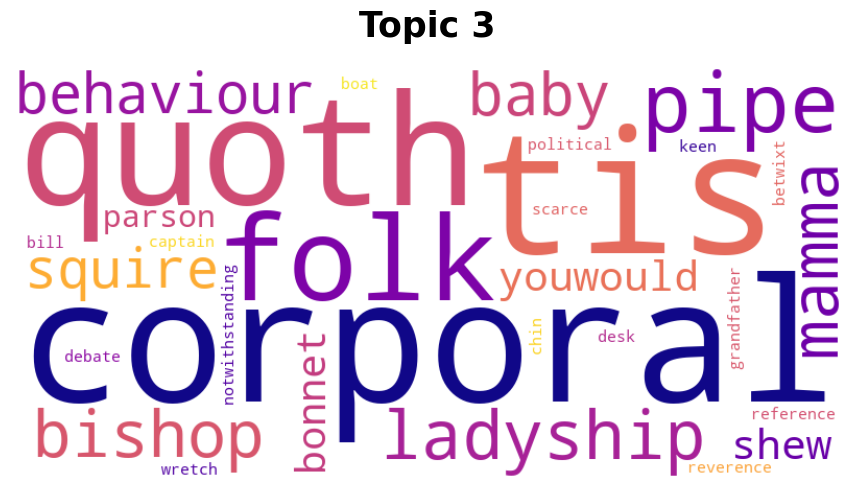

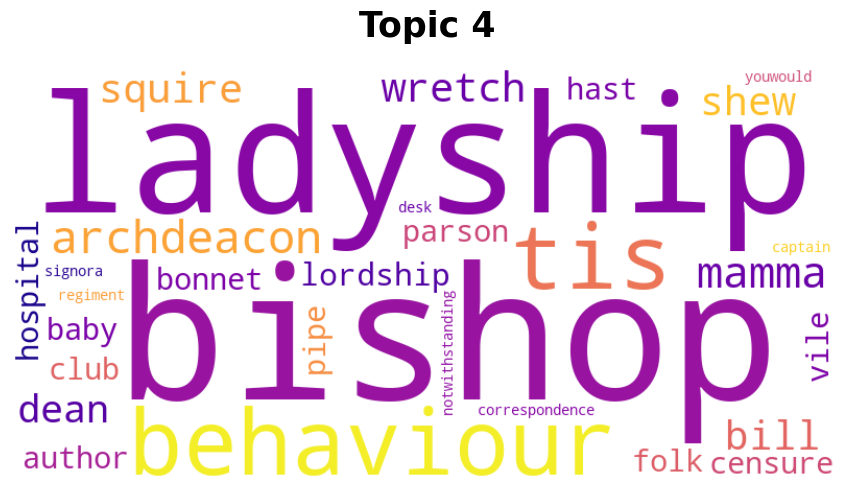

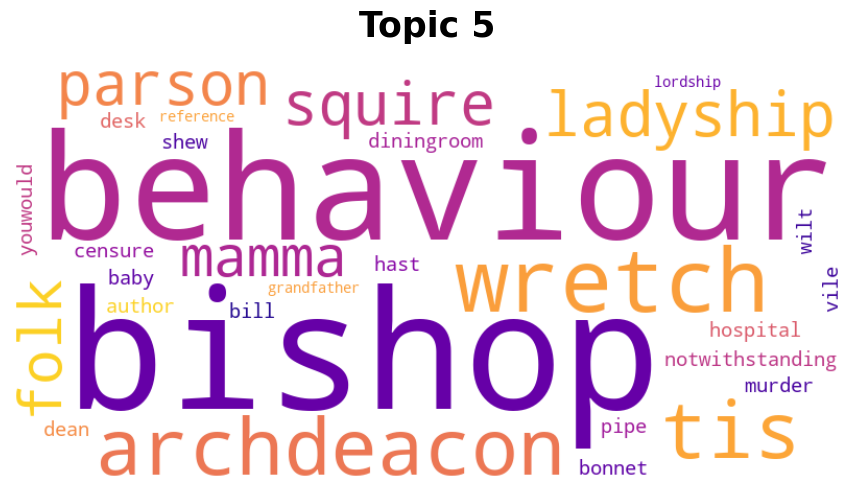

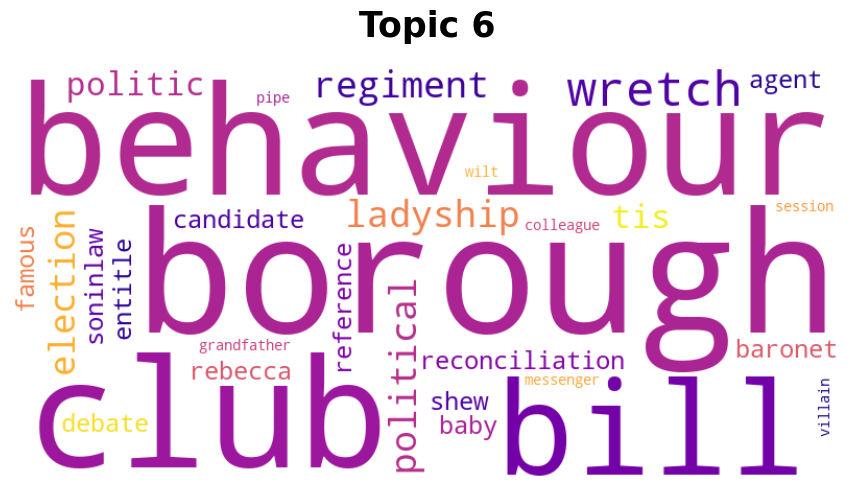

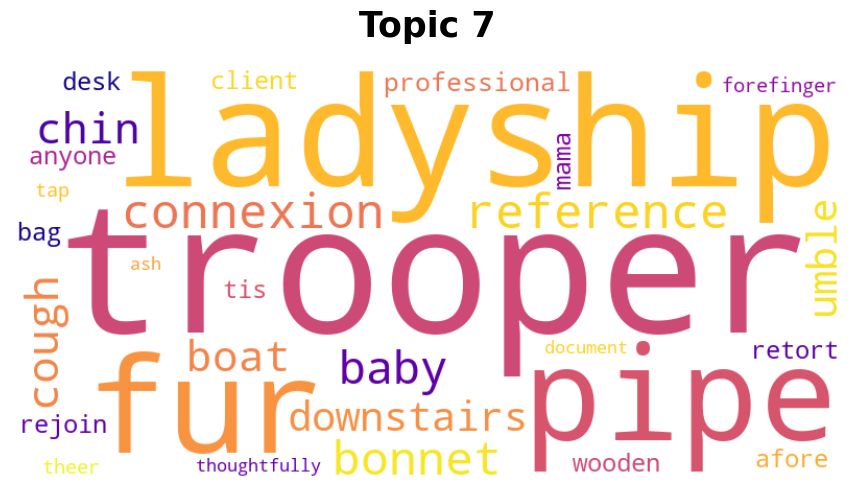

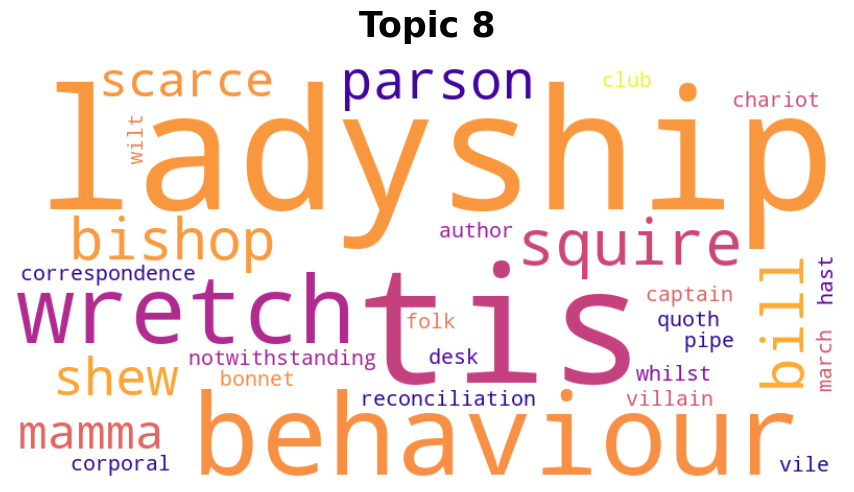

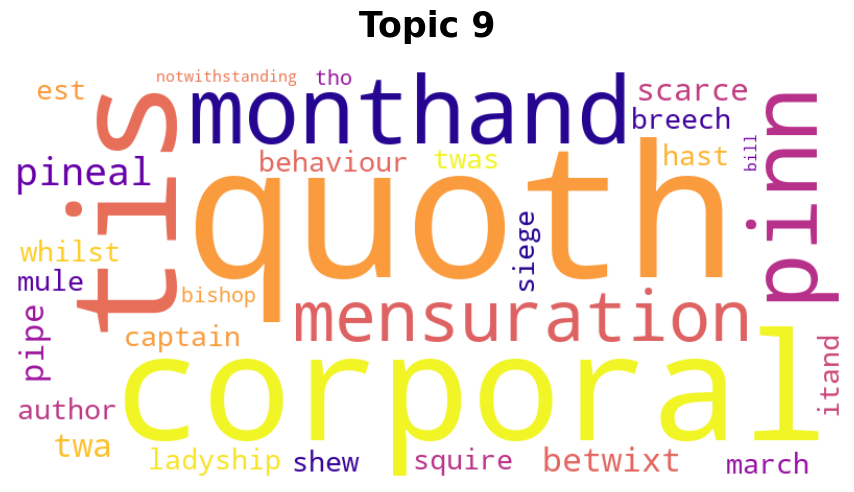

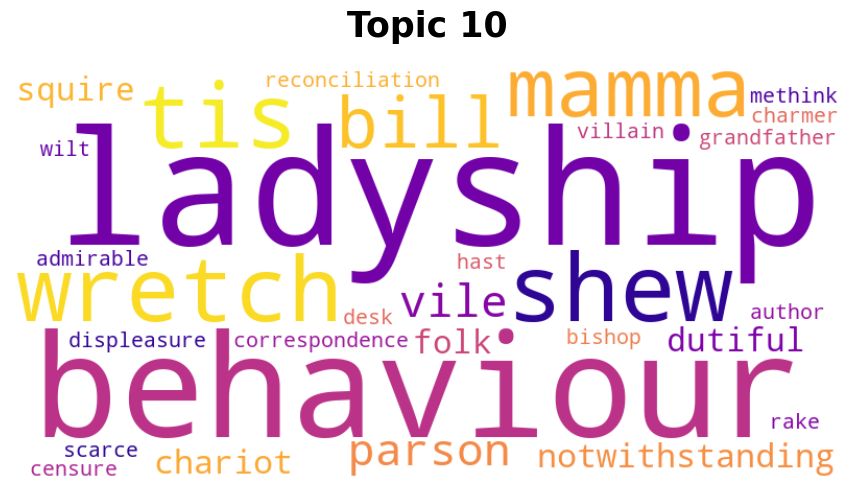

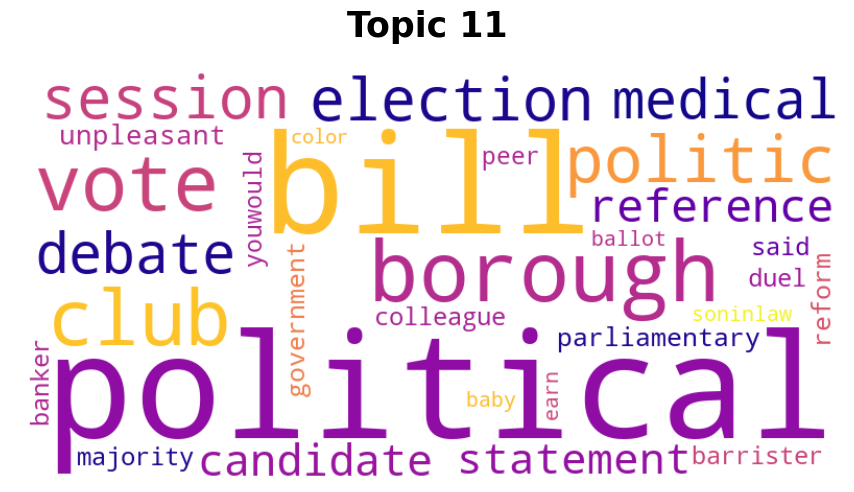

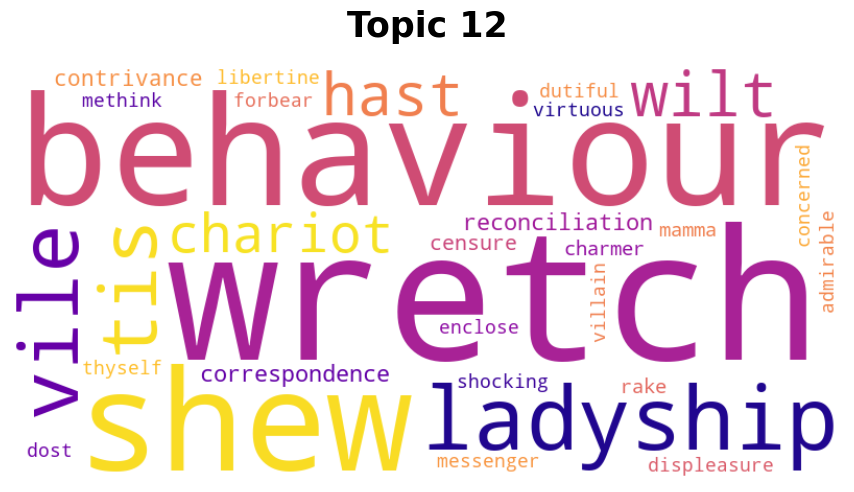

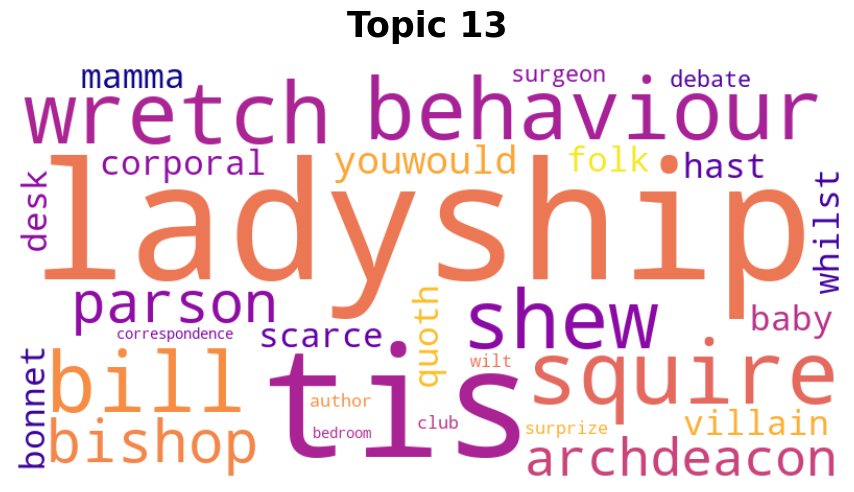

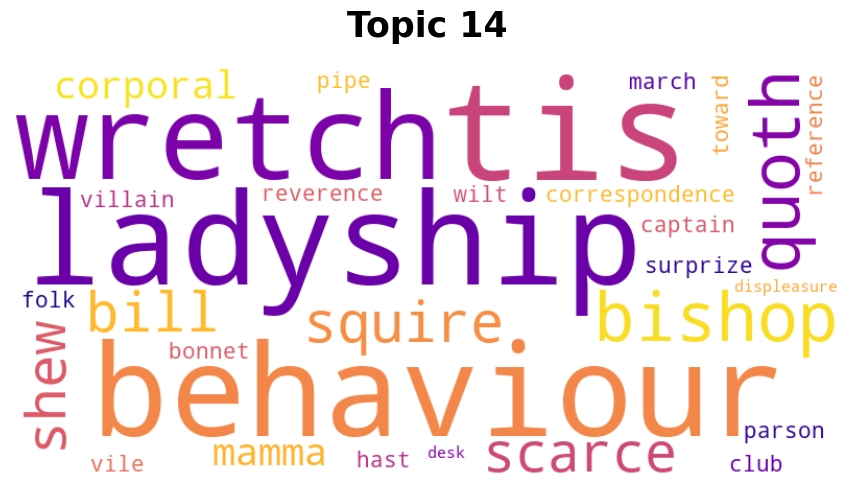

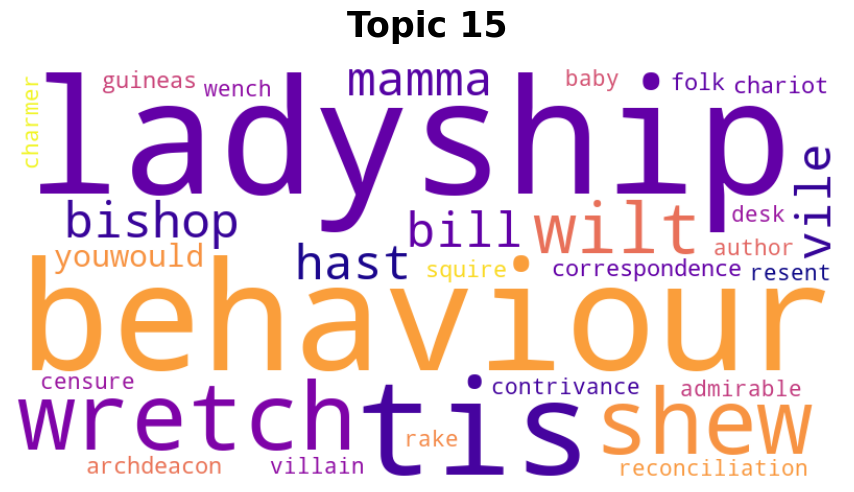

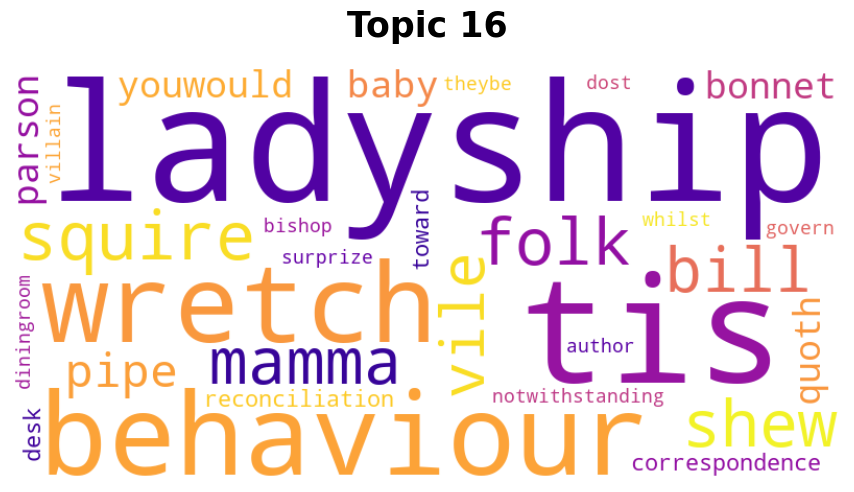

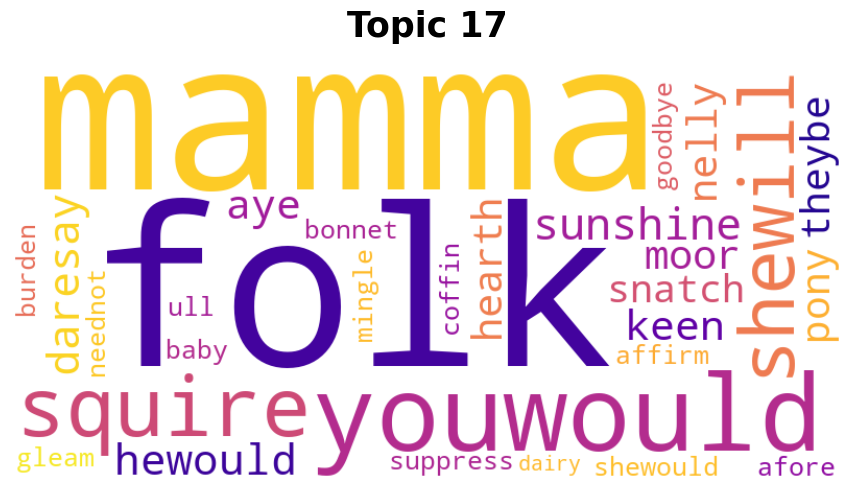

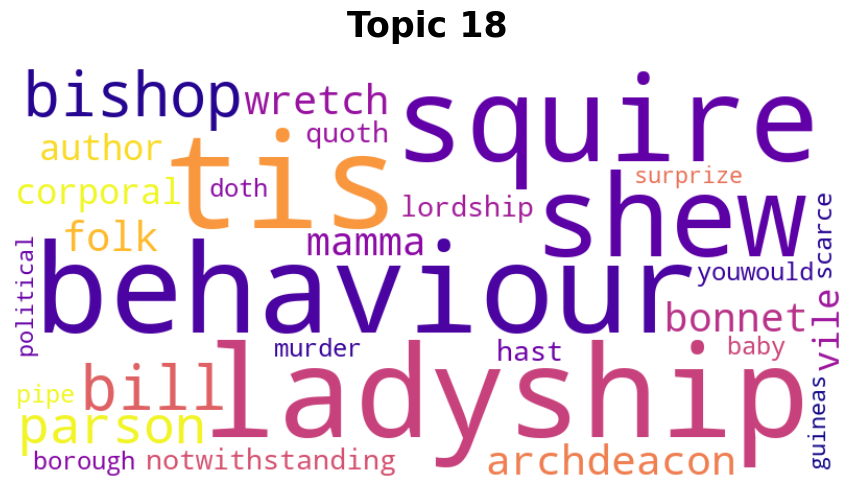

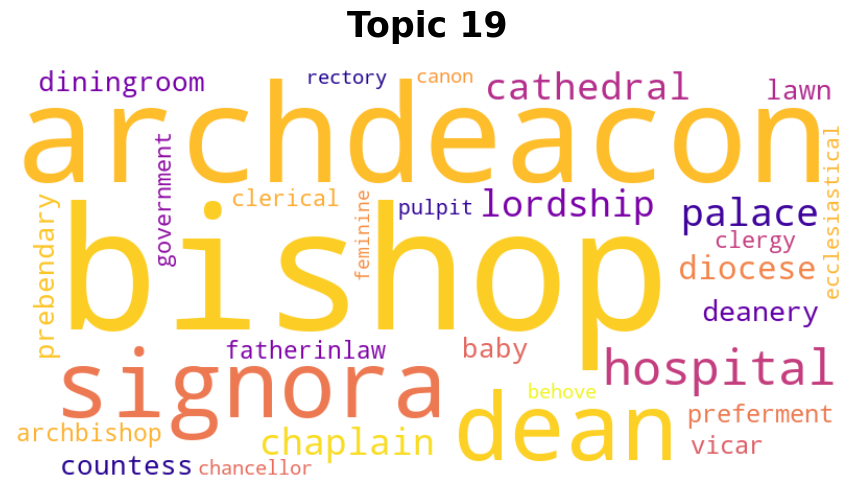

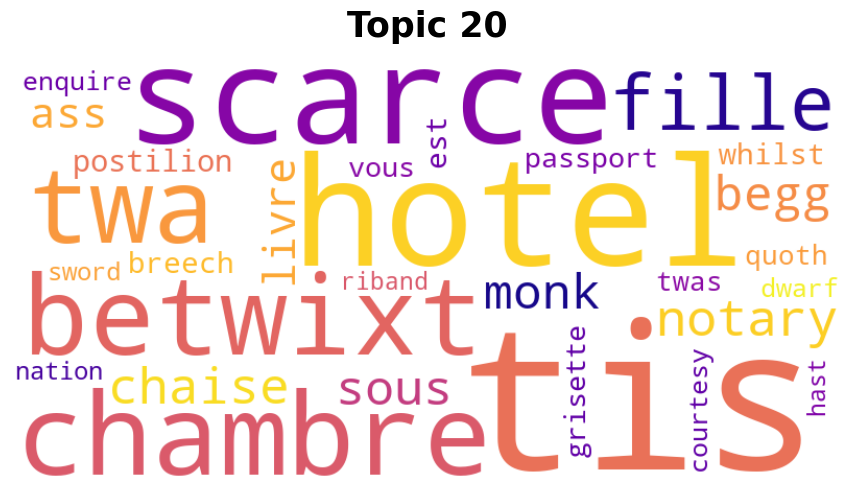

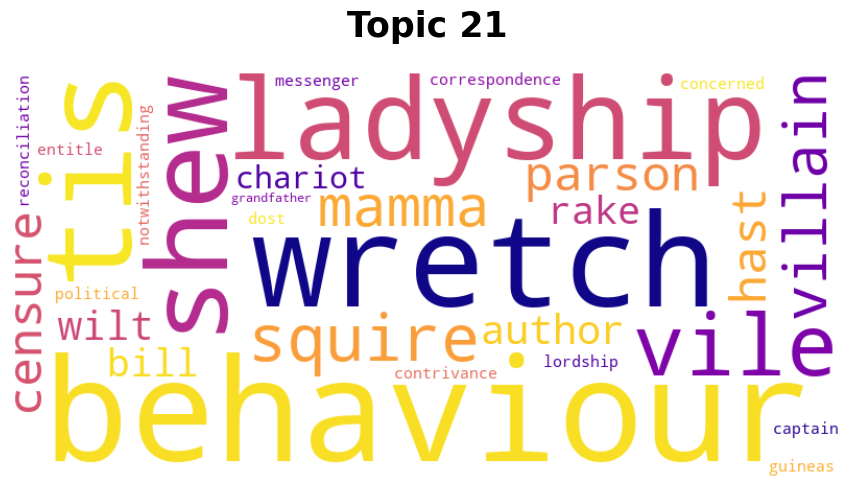

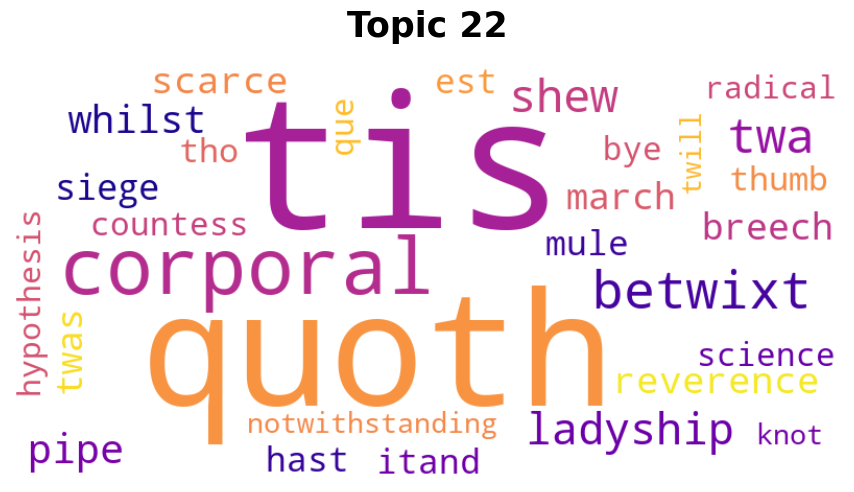

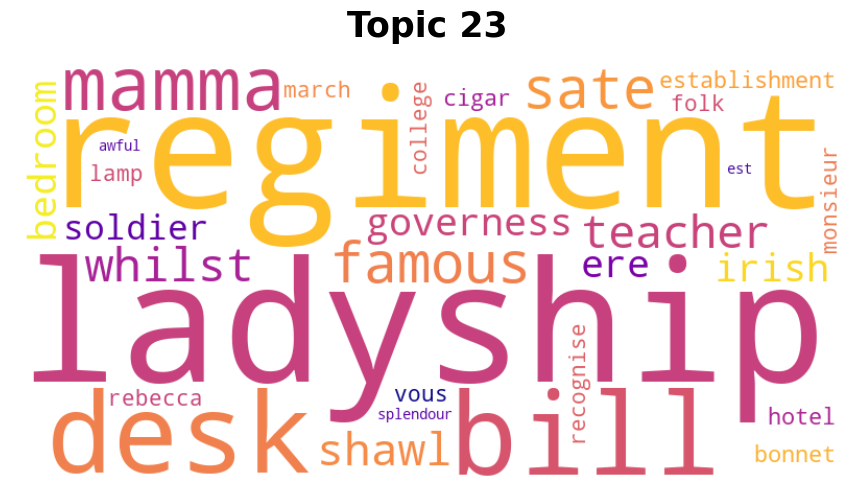

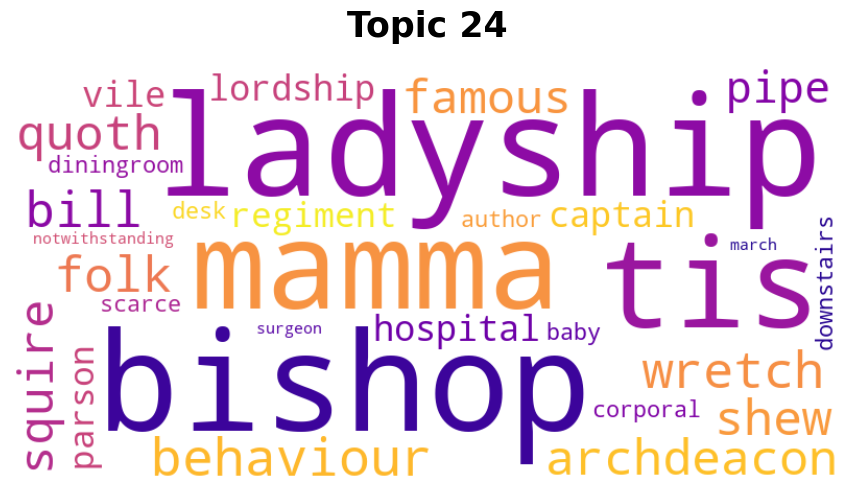

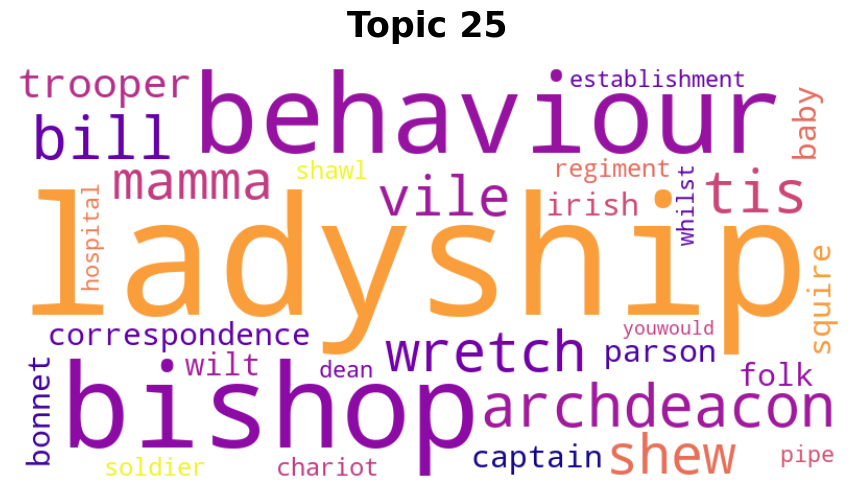

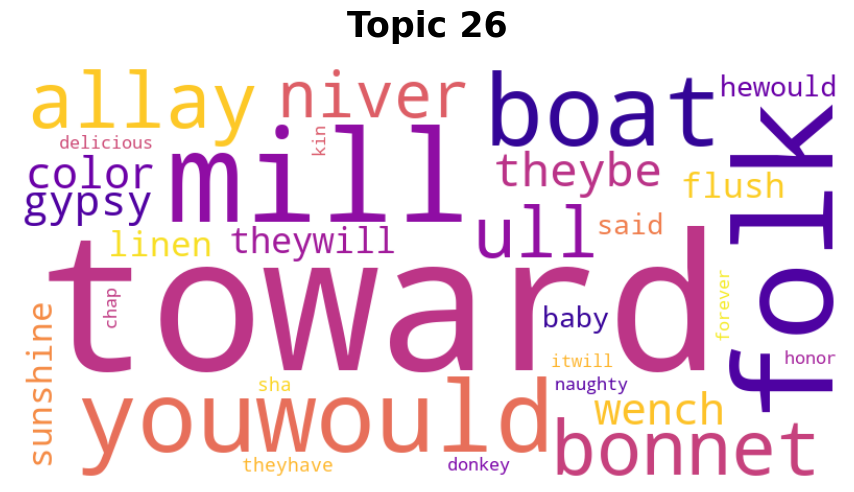

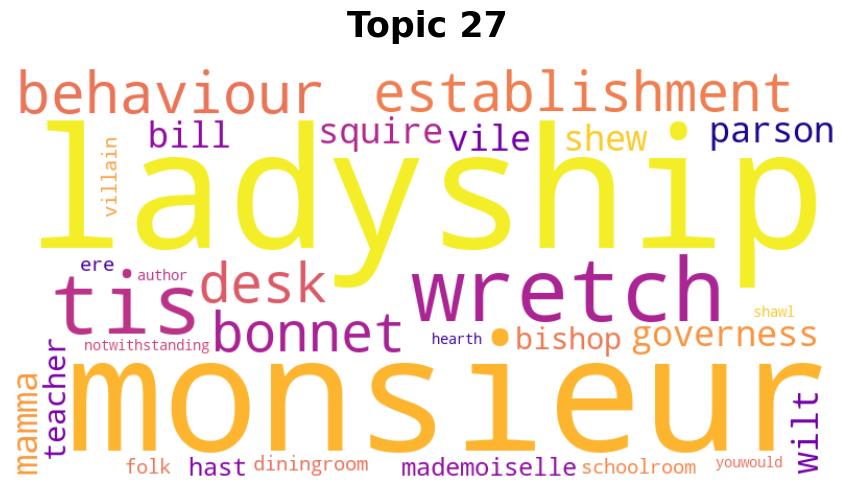

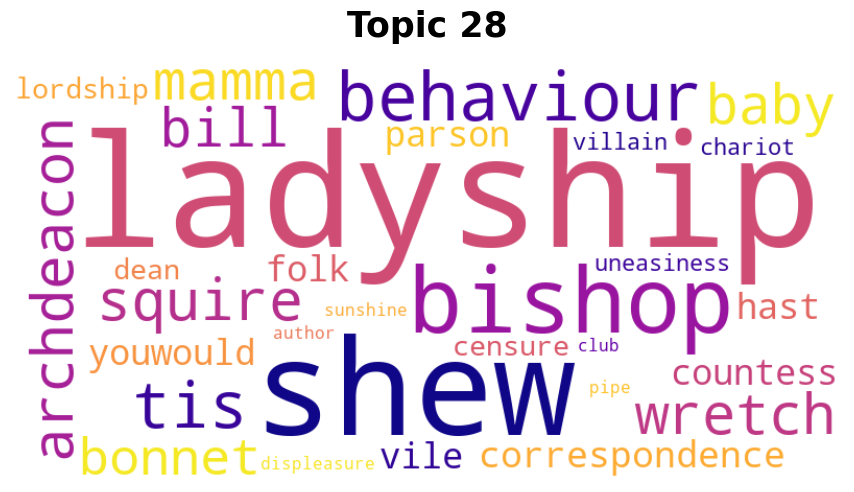

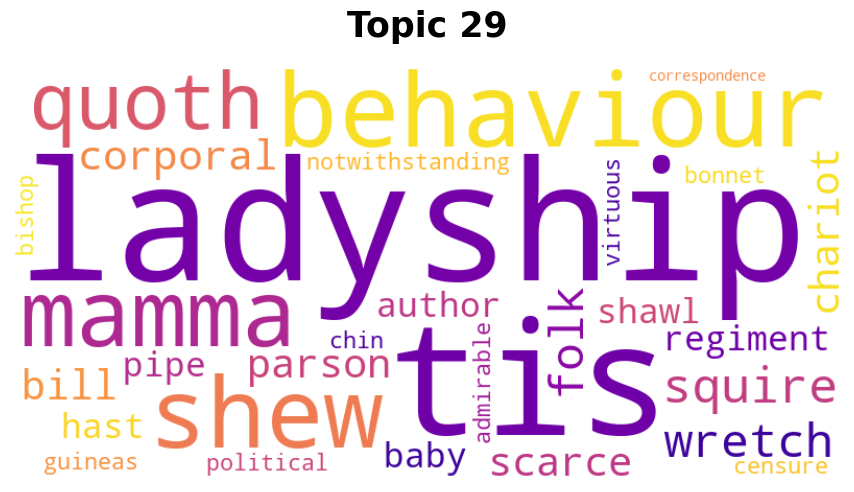

In [10]:
topic_wordclouds (lda_model, max_words = 30, colormap = 'plasma')

In [11]:
top_documents_per_topic (lda_model, processed, dictionary, n=3)

+----------+---------------------------------------------+------------------------------------------+-----------------------------------------+
| Topic    | Doc 1                                       | Doc 2                                    | Doc 3                                   |
+----------+---------------------------------------------+------------------------------------------+-----------------------------------------+
| Topic 0  | Sterne_Sentimental_lemmatized.txt (0.0%)    | ABronte_Agnes_lemmatized.txt (0.0%)      | Austen_Pride_lemmatized.txt (0.0%)      |
| Topic 1  | Sterne_Sentimental_lemmatized.txt (0.0%)    | ABronte_Agnes_lemmatized.txt (0.0%)      | Austen_Pride_lemmatized.txt (0.0%)      |
| Topic 2  | Austen_Emma_lemmatized.txt (98.5%)          | Fielding_Tom_lemmatized.txt (85.0%)      | Austen_Sense_lemmatized.txt (60.8%)     |
| Topic 3  | Sterne_Sentimental_lemmatized.txt (0.0%)    | ABronte_Agnes_lemmatized.txt (0.0%)      | Austen_Pride_lemmatized.txt (0.0%)

In [ ]:
fig = document_topic_heatmap(lda_model, processed, dictionary)

Training LDA: num_topics=10, passes=15 ...
Done. Model has 10 topics over a vocabulary of 23,741 words.
Training LDA: num_topics=20, passes=15 ...
Done. Model has 20 topics over a vocabulary of 23,741 words.
Training LDA: num_topics=30, passes=15 ...
Done. Model has 30 topics over a vocabulary of 23,741 words.


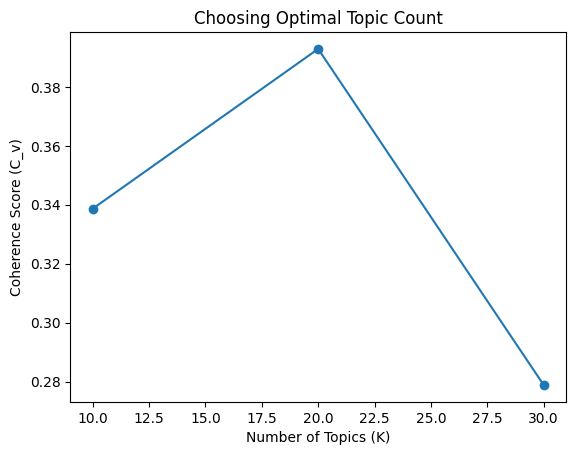

In [12]:
target_range = [10, 20, 30]
find_optimal_coherence (processed, dictionary, target_range)

In [ ]:
def generate_html (model, processed, dictionary, filename = 'lda_visualization.html'):
    documents = list(processed.values())
    bow_corpus = [dictionary.doc2bow(doc) for doc in documents]
    vis_data = gensimvis.prepare (
        topic_model = model,      # Your trained Gensim LdaModel or LdaMulticore
        corpus = bow_corpus,              # The Bag-of-Words corpus used for training
        dictionary = dictionary,      # The Gensim Dictionary object
        sort_topics = True            # Sorts topics by total document frequency
    )

    # 2. Display the interactive chart directly inside a Jupyter Notebook
    pyLDAvis.enable_notebook ()
    pyLDAvis.display (vis_data)

    # 3. Alternative: Save the visualization as a standalone HTML file
    # This is perfect for sharing results with colleagues or embedding in a research folder
    pyLDAvis.save_html (vis_data, filename)
generate_html (lda_model, processed, dictionary)